       INFORME DE ANÁLISIS DE SEGURIDAD Y VULNERABILIDADES
Total de hallazgos registrados: 311
Total de repositorios afectados: 28

--- 1. Distribución y Riesgo por Severidad ---
  * CRITICAL  :    3 hallazgos (1.0%)
  * HIGH      :  120 hallazgos (38.6%)
  * MEDIUM    :  161 hallazgos (51.8%)
  * LOW       :   27 hallazgos (8.7%)


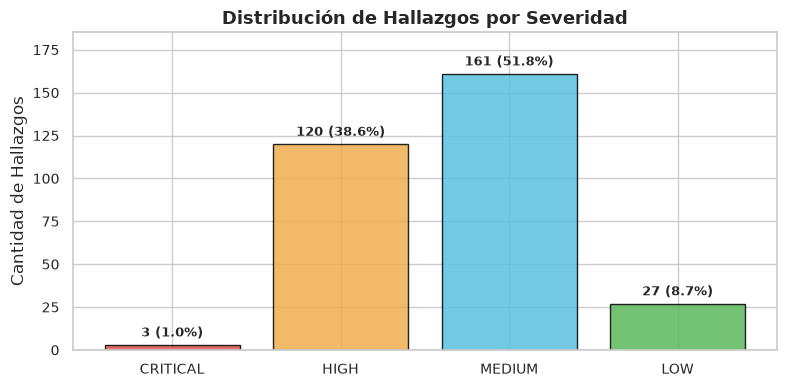


--- 2. Origen de Hallazgos por Herramienta ---
  * grype          :  156 hallazgos (50.2%)
  * codeql         :  155 hallazgos (49.8%)


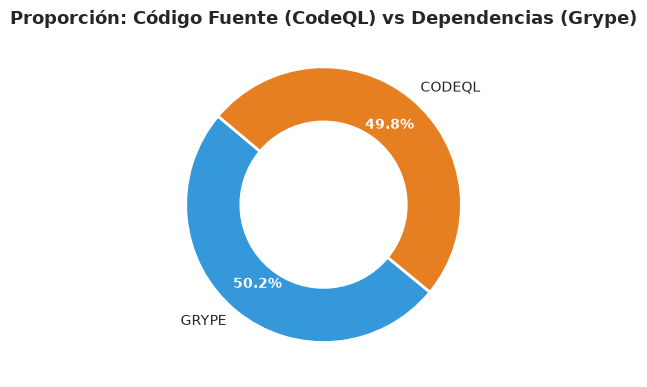


--- 3. Patrones: Nivel de Severidad según la Herramienta ---
severity  critical  high  medium  low
tool                                 
codeql           1    76      78    0
grype            2    44      83   27


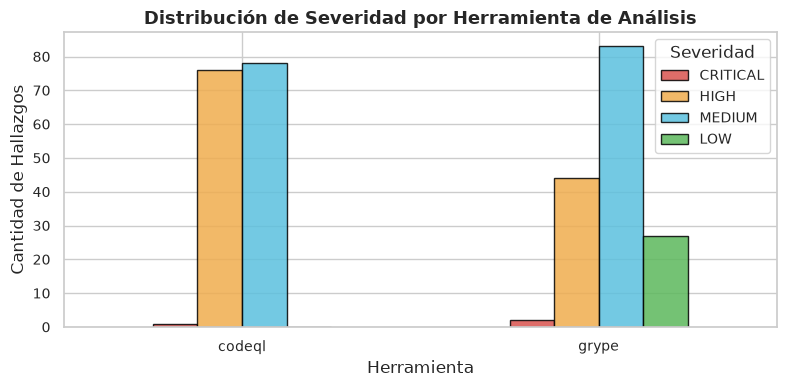


--- 4. Concentración de Riesgo (Top 5 Repositorios) ---
  * setuptools-scm                     :   56 hallazgos
  * browntruck                         :   48 hallazgos
  * hatch                              :   41 hallazgos
  * pipfile                            :   24 hallazgos
  * pipenv                             :   19 hallazgos


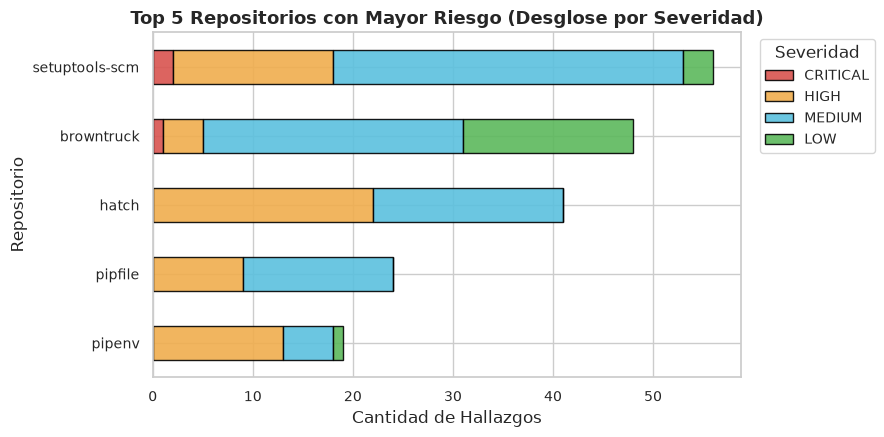


--- 5. Top 10 Reglas/CWEs Más Frecuentes (CWE) ---
  * CWE-829                            :   44 ocurrencias
  * CWE-275                            :   29 ocurrencias
  * CWE-22                             :   24 ocurrencias
  * CWE-732                            :   14 ocurrencias
  * CWE-20                             :   11 ocurrencias
  * CWE-79                             :   10 ocurrencias
  * CWE-327, CWE-328, CWE-916          :    8 ocurrencias
  * CWE-327                            :    5 ocurrencias
  * CWE-94, CWE-95, CWE-116            :    5 ocurrencias
  * CWE-312, CWE-359, CWE-532          :    2 ocurrencias


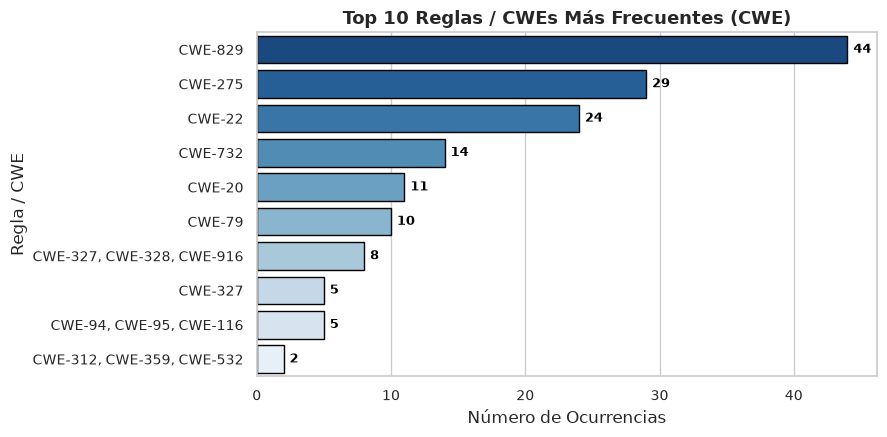

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ==========================================
# 0. CONFIGURACIÓN GLOBAL DE ESTILOS VISUALES
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 15
})

# Mapa unificado de colores por severidad
COLOR_MAP = {
    'critical': '#d9534f',
    'high': '#f0ad4e',
    'medium': '#5bc0de',
    'low': '#5cb85c',
    'info': '#6c757d'
}

SEV_ORDER = ['critical', 'high', 'medium', 'low', 'info']

# ==========================================
# 1. CONFIGURAR RUTAS Y CARGAR DATASETS
# ==========================================
RESULTS_FOLDER = Path("../results")
TOOL_ANALYSIS_FOLDER = RESULTS_FOLDER / "tool-analysis"
TOOL_ANALYSIS_FOLDER.mkdir(parents=True, exist_ok=True)

findings_df = pd.read_csv(RESULTS_FOLDER / "dataset/findings.csv")
repos_df = pd.read_csv(RESULTS_FOLDER / "dataset/repos.csv")

# Homogeneizar texto de severidad a minúsculas
findings_df['severity'] = findings_df['severity'].astype(str).str.lower()

total_findings = len(findings_df)
total_repos = findings_df['repo'].nunique()

print("=" * 65)
print("       INFORME DE ANÁLISIS DE SEGURIDAD Y VULNERABILIDADES")
print("=" * 65)
print(f"Total de hallazgos registrados: {total_findings}")
print(f"Total de repositorios afectados: {total_repos}\n")

# ==========================================
# ANÁLISIS 1: Distribución por Severidad
# ==========================================
print("--- 1. Distribución y Riesgo por Severidad ---")
severity_counts = findings_df['severity'].value_counts()
existing_order = [s for s in SEV_ORDER if s in severity_counts.index]
severity_counts = severity_counts.reindex(existing_order)

for severity, count in severity_counts.items():
    pct = (count / total_findings) * 100
    print(f"  * {severity.upper():<10}: {count:>4} hallazgos ({pct:.1f}%)")

severity_summary = severity_counts.reset_index()
severity_summary.columns = ['severity', 'count']
severity_summary.to_json(TOOL_ANALYSIS_FOLDER / "severity_summary.json", orient='records', indent=4)

# Gráfico 1: Severidad con valores sobre las barras
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [COLOR_MAP.get(s, '#777777') for s in severity_counts.index]
bars = ax.bar([s.upper() for s in severity_counts.index], severity_counts.values, color=bar_colors, edgecolor='black', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    pct = (yval / total_findings) * 100
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + (total_findings * 0.01), f'{yval} ({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_title("Distribución de Hallazgos por Severidad", fontweight='bold')
ax.set_ylabel("Cantidad de Hallazgos")
ax.set_ylim(0, max(severity_counts.values) * 1.15)
plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISIS 2: Comparativa por Herramienta
# ==========================================
print("\n--- 2. Origen de Hallazgos por Herramienta ---")
tool_counts = findings_df['tool'].value_counts()
for tool, count in tool_counts.items():
    pct = (count / total_findings) * 100
    print(f"  * {tool:<15}: {count:>4} hallazgos ({pct:.1f}%)")

tool_summary = tool_counts.reset_index()
tool_summary.columns = ['tool', 'count']
tool_summary.to_json(TOOL_ANALYSIS_FOLDER / "tool_summary.json", orient='records', indent=4)

# Gráfico 2: Herramientas (Donut Chart)
fig, ax = plt.subplots(figsize=(6, 4))
colors_tools = ['#3498db', '#e67e22'] if len(tool_counts) == 2 else sns.color_palette("Set2")
wedges, texts, autotexts = ax.pie(
    tool_counts, 
    labels=[t.upper() for t in tool_counts.index], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_tools,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)
plt.setp(autotexts, size=10, weight="bold", color="white")
ax.set_title("Proporción: Código Fuente (CodeQL) vs Dependencias (Grype)", fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISIS 3: Cruce Severidad por Herramienta
# ==========================================
print("\n--- 3. Patrones: Nivel de Severidad según la Herramienta ---")
cross_tool_sev = pd.crosstab(findings_df['tool'], findings_df['severity'])
cross_cols = [s for s in SEV_ORDER if s in cross_tool_sev.columns]
cross_tool_sev = cross_tool_sev[cross_cols]
print(cross_tool_sev)

cross_tool_sev.reset_index().to_json(TOOL_ANALYSIS_FOLDER / "tool_severity_cross.json", orient='records', indent=4)

# Gráfico 3: Severidad comparada por Herramienta
fig, ax = plt.subplots(figsize=(8, 4))
cross_tool_sev.plot(
    kind='bar', 
    ax=ax, 
    color=[COLOR_MAP.get(c, '#777777') for c in cross_cols], 
    edgecolor='black', 
    alpha=0.85
)
ax.set_title("Distribución de Severidad por Herramienta de Análisis", fontweight='bold')
ax.set_xlabel("Herramienta")
ax.set_ylabel("Cantidad de Hallazgos")
plt.xticks(rotation=0)
plt.legend(title="Severidad", labels=[s.upper() for s in cross_cols])
plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISIS 4: Concentración en Top 5 Repositorios
# ==========================================
print("\n--- 4. Concentración de Riesgo (Top 5 Repositorios) ---")
top_repos_list = findings_df['repo'].value_counts().head(5).index
df_top5 = findings_df[findings_df['repo'].isin(top_repos_list)]

for repo in top_repos_list:
    count = len(findings_df[findings_df['repo'] == repo])
    print(f"  * {repo:<35}: {count:>4} hallazgos")

# Matriz cruzada para gráfico de barras apiladas
repo_sev_matrix = pd.crosstab(df_top5['repo'], df_top5['severity'])
repo_sev_cols = [s for s in SEV_ORDER if s in repo_sev_matrix.columns]
repo_sev_matrix = repo_sev_matrix.loc[top_repos_list][repo_sev_cols]

# Exportar JSON
top_repos_df = findings_df['repo'].value_counts().head(5).reset_index()
top_repos_df.columns = ['repo_name', 'count']
top_repos_df.to_json(TOOL_ANALYSIS_FOLDER / "top_repos.json", orient='records', indent=4)

# Gráfico 4: Barras Apiladas por Severidad (Stacked Bar Chart)
fig, ax = plt.subplots(figsize=(9, 4.5))
repo_sev_matrix.plot(
    kind='barh', 
    stacked=True, 
    ax=ax, 
    color=[COLOR_MAP.get(c, '#777777') for c in repo_sev_cols], 
    edgecolor='black', 
    alpha=0.9
)
ax.set_title("Top 5 Repositorios con Mayor Riesgo (Desglose por Severidad)", fontweight='bold')
ax.set_xlabel("Cantidad de Hallazgos")
ax.set_ylabel("Repositorio")
ax.invert_yaxis()
ax.legend(title="Severidad", labels=[s.upper() for s in repo_sev_cols], bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# ANÁLISIS 5: Top 10 Reglas / CWEs Más Frecuentes
# ==========================================
cwe_col = 'cwe' if 'cwe' in findings_df.columns and findings_df['cwe'].notna().sum() > 0 else 'vuln_id'
top_rules = findings_df[cwe_col].value_counts().head(10)

print(f"\n--- 5. Top 10 Reglas/CWEs Más Frecuentes ({cwe_col.upper()}) ---")
for rule, count in top_rules.items():
    print(f"  * {str(rule):<35}: {count:>4} ocurrencias")

top_rules_df = top_rules.reset_index()
top_rules_df.columns = ['rule_or_cwe', 'count']
top_rules_df.to_json(TOOL_ANALYSIS_FOLDER / "top_rules.json", orient='records', indent=4)

fig, ax = plt.subplots(figsize=(9, 4.5))
rules_y = [str(r) for r in top_rules.index]

sns.barplot(
    x=top_rules.values, 
    y=rules_y, 
    hue=rules_y,           
    palette="Blues_r", 
    legend=False,          
    ax=ax, 
    edgecolor="black"
)
ax.set_title(f"Top 10 Reglas / CWEs Más Frecuentes ({cwe_col.upper()})", fontweight='bold')
ax.set_xlabel("Número de Ocurrencias")
ax.set_ylabel("Regla / CWE")

for i, v in enumerate(top_rules.values):
    ax.text(v + (max(top_rules.values)*0.01), i, str(v), color='black', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Informe de Análisis de Seguridad y Vulnerabilidades
**Componente:** Analyzer (Segundo Integrante)  
**Alcance:** 28 Repositorios auditados | 311 Hallazgos totales  

---

## 1. Introducción y Contexto
El presente análisis evalúa la postura de seguridad de **28 repositorios** de la organización objetivo mediante herramientas de Análisis Estático de Código SAST (**CodeQL**) y análisis de dependencias SCA/SBOM (**Grype**).

> **Objetivo:** Identificar concentraciones de riesgo, patrones de vulnerabilidad recurrentes y estructurar los datasets procesados para su posterior consumo en el dashboard interactivo (**Visualizer**).

---

## 2. Resultados Principales y Distribución de Riesgo

| Métrica | Valor | Observación |
| :--- | :--- | :--- |
| **Total Hallazgos** | **311** | Registrados en el dataset unificado |
| **Repositorios Afectados** | **28** | 100% de la muestra evaluada |
| **Severidad Crítica** | **3 (1.0%)** | Requieren atención e intervención inmediata |
| **Severidad Alta** | **120 (38.6%)** | Elevado riesgo de explotación |
| **Severidad Media** | **161 (51.8%)** | Principal volumen de hallazgos (cadena de suministro) |
| **Severidad Baja** | **27 (8.6%)** | Oportunidades de mejora y hardening de código |

---

## 3. Patrones Identificados e Impacto Organizacional

1. **Equilibrio de Vectores de Ataque (SAST vs. SCA):**
   * **CodeQL (Código Fuente):** 155 hallazgos (49.8%).
   * **Grype (Dependencias / SBOM):** 156 hallazgos (50.2%).
   * *Conclusión:* El riesgo está distribuido equitativamente entre errores de codificación propia y vulnerabilidades heredadas en librerías de terceros.

2. **Concentración del Riesgo (Principio de Pareto):**
   * El **90.4% de los hallazgos** se concentra en severidades Media y Alta (281 vulnerabilidades).
   * Repositorios con mayor densidad de fallas: `setuptools-scm` (56), `browntruck` (48) y `hatch` (41).

3. **Debilidades Más Frecuentes (Top CWEs):**
   * Predominancia de **CWE-829** (Inclusión de dependencias de terceros no confiables) y **CWE-275** (Permisos deficientes o inseguros).

   ---

## 4. Conclusiones y Plan de Acción

> **Plan de Mitigación Recomendado:**
> 1. **Prioridad 1 (Inmediata):** Corregir de manera prioritaria las **3 vulnerabilidades Críticas** y las **120 de nivel Alto**.
> 2. **Prioridad 2 (Cadena de Suministro):** Actualizar las dependencias reportadas por Grype para eliminar los 161 hallazgos de nivel Medio.
> 3. **Prioridad 3 (Foco en Repos Críticos):** Concentrar los esfuerzos del equipo de desarrollo en el Top 5 de repositorios (`setuptools-scm`, `browntruck`, `hatch`, `pipfile`, `pipenv`).

---
*Archivos JSON generados y estructurados exitosamente en `results/tool-analysis/` para la fase de Visualización.*